<a href="https://colab.research.google.com/github/amnasyed1/nyc-geospatial-public-health-foodallergy/blob/main/Manhattan_FoodAllergyRestaurantAwareness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries**

In [118]:
# Installing Libraries

# for data processing and manipulation
import pandas as pd
import numpy as np
import csv

# for data visualization
import matplotlib.pyplot as plt #for data visualization (graphs and plots)
import seaborn as sns #for data visualization
import missingno as msno

# Geospatial Analysis
import geopandas as gpd
from matplotlib import colormaps

# **Project Objective & Dataset Description**

**Project Objective:**

This analysis investigates the geospatial distribution of NYCDOHMH restaurant health violations in Manhattan with a special focus on food allergy safety. To accomplish this, allergy-specific regulatory compliance (Poster Violation 20-01) and broader safety risks (such as cross-contamination) were isolated. This project utilizes statistical methods such as normalized statistics and geospatial visualizations to identify neighborhood-level risk assessments in terms of food allergies and public health trends.

**A Note on the Data Ethics & Bias Mitigation:**

> While this analysis identifies geographic areas of health violations, it is important to analyze & interpret the findings with empathetic care & intention:
 > - Higher violation rates in specific zip codes do not reflect the character of the neighborhood nor should create any type of neighborhood bias.
  > - This analysis does not aim to stigmatize or isolate any specific neighborhoods, cuisines, food cultures, or communities.

**The goal of this project is purely to advocate for public health awareness & food allergy awareness and to identify where educational resources such as the food allergy posters might be needed to protect vulnerable individuals.**



## **Data Description**


This dataset contains every violation from every inspection conducted in active restaurants in Manhattan between 2025 Apr 07 02:55:51 PM and 2026 Apr 07 02:55:51 PM. You will find below the descriptions of each column in the dataset.

>**DATA SOURCE:** https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data

**Column Descriptions**

CAMIS = The unique restaurant identifier (essential for calculating unique restaurant counts per neighborhood).

DBA = The business name

BORO = Borough in which the restaurant is located • 1 = MANHATTAN • 2 = BRONX • 3 = BROOKLYN • 4 = QUEENS • 5 = STATEN ISLAND

ZIPCODE = Zip code of restaurant's location

CUISINE DESCRIPTION = Used to identify if specific food types have higher allergy-related risks depending on the allergic individual


VIOLATION CODE = This was used as a source for keyword filtering (e.g., "cross-contact"); the violation code associated with an restaurant inspection

VIOLATION DESCRIPTION = This was used as a source for keyword filtering (e.g., "cross-contact"); violation description associated with an restaurant's inspection

CRITICAL FLAG = This was used to weigh the severity of food safety risks; Indicator of critical violation; "• Critical • Not Critical • Not Applicable"

SCORE = Total score for a particular inspection; the high-level indicators of overall establishment hygiene

GRADE = Grade associated with the inspection; • N = Not Yet Graded• A = Grade A• B = Grade B• C = Grade C• Z = Grade Pending• P= Grade Pending issued on re-opening following an initial inspection that resulted in a closure; the high-level indicators of overall establishment hygiene

Latitude = latitude
Longitude = longitude
  - The primary coordinates used for visualizations, mapping, and the density analysis.

NTA = Neighborhood Tabulation Areas (NTAs) were used for more high-level statistical reporting than zip codes.

Location = the latitude & longitude points

In [119]:
# Loading the CSV Data
# Filtered the dataset by borough (Manhattan) and the inspection date to 12 months prior from 4/07/25 to 4/07/26
# Setup Instructions: Upload the CSV into Colab's 'files' section, right-click the file to 'copy path', and paste it directly into the `pd.read_csv()` function below.
data = pd.read_csv('/content/DOHMH_New_York_City_Restaurant_Inspection_Results_20260407.csv')
data.head(10)

/tmp/ipykernel_14518/2990376379.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/DOHMH_New_York_City_Restaurant_Inspection_Results_20260407.csv')


,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50161091,7TH HEAVEN PIZZA,Manhattan,2496,ADAM CLAYTON POWELL JR BOULEVARD,NaN,6469273600,Pizza,05/06/2025,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
1,50044252,OPEN MARKET,Manhattan,15,WILLIAM STREET,10005.0,2127855555,American,08/20/2025,No violations were recorded at the time of thi...,...,Administrative Miscellaneous / Initial Inspection,40.705201,-74.009998,101.0,1.0,900.0,1087954.0,1.000258e+09,MN25,POINT (-74.009997887352 40.705201361926)
2,41510846,218 RESTAURANT,Manhattan,218220,GRAND STREET,NaN,2122268039,Chinese,04/21/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
3,50100008,DAN JONES COFFEE BAR,Manhattan,954,3 AVENUE,10022.0,3477202119,Coffee/Tea,11/20/2025,No violations were recorded at the time of thi...,...,Administrative Miscellaneous / Initial Inspection,40.760348,-73.967386,106.0,4.0,11203.0,1036912.0,1.013120e+09,MN19,POINT (-73.967386006202 40.760347720672)
4,50105206,JAJAJA MEXICANA,Manhattan,63,CARMINE STREET,10014.0,9172620184,Mexican,03/23/2026,Establishment re-closed by DOHMH.,...,Cycle Inspection / Reopening Inspection,40.729723,-74.004355,102.0,3.0,6700.0,1009769.0,1.005820e+09,MN23,POINT (-74.004354945112 40.729723473067)
5,50114231,DESPANA,Manhattan,408,BROOME STREET,10013.0,3473072564,Tapas,10/29/2025,No violations were recorded at the time of thi...,...,Administrative Miscellaneous / Initial Inspection,40.720910,-73.997825,102.0,1.0,4500.0,1066733.0,1.004828e+09,MN24,POINT (-73.997824620303 40.7209100901)
6,41606171,IHOP,Manhattan,235237,EAST 14 STREET,NaN,2123881499,Pancakes/Waffles,08/14/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
7,50131689,SIDE BAR,Manhattan,NaN,AMTRACK LEVEL,10001.0,7329952865,Bottled Beverages,09/17/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,50170785,CD&R,Manhattan,550,MADISON AVENUE,10022.0,2123376092,American,06/07/2025,No violations were recorded at the time of thi...,...,Inter-Agency Task Force / Initial Inspection,40.761082,-73.973252,105.0,4.0,10200.0,1035769.0,1.012910e+09,MN17,POINT (-73.973251536579 40.761082088223)
9,50033660,RUSTY'S FLAVOR,Manhattan,2261,ADAM CLAYTON POWELL JR BOULEVARD,NaN,2123683403,Caribbean,03/04/2026,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN


# **Data Cleaning**

In [120]:
data.columns

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location'],
      dtype='object')

## **Handling Missing Values**

- several different columns have missing values, as seen by utilizing the code `print(data.isnull().sum())`. By utilizing the code, `print(data.isnull().sum(axis=1))`, one can get a closer look at the missing values in each row, which indicates that most rows do in fact include missing values.

- However, removing all rows which contain missing values will then subsequently eliminate important data needed to explore the main objectives of the analysis. Therefore, I utilized the code `data.dropna(subset=['ZIPCODE', 'VIOLATION DESCRIPTION'], inplace=True)`, dropping rows which had missing values in `ZIPCODE` and `VIOLATION DESCRIPTION`, as those two columns are crucial to meet the main objectives of the analysis.

In [121]:
# Checking for missing values in a column
print(data['CAMIS'].isnull().sum())
print(data['DBA'].isnull().sum())
print(data['BORO'].isnull().sum())
print(data['BUILDING'].isnull().sum())

0
0
0
85


In [122]:
# Checking all columns for missing values
print(data.isnull().sum())

CAMIS                        0
DBA                          0
BORO                         0
BUILDING                    85
STREET                       0
ZIPCODE                    419
PHONE                        0
CUISINE DESCRIPTION          0
INSPECTION DATE              0
ACTION                       0
VIOLATION CODE             443
VIOLATION DESCRIPTION      443
CRITICAL FLAG                0
SCORE                     1799
GRADE                    15452
GRADE DATE               18058
RECORD DATE                  0
INSPECTION TYPE              0
Latitude                   150
Longitude                  150
Community Board            569
Council District           569
Census Tract               569
BIN                        721
BBL                        150
NTA                        569
Location                   569
dtype: int64


In [123]:
# Count of the missing values in each row
print(data.isnull().sum(axis=1))

0        7
1        5
2        7
3        5
4        2
        ..
33924    2
33925    2
33926    0
33927    0
33928    9
Length: 33929, dtype: int64


In [124]:
#Fill missing 'GRADES' with "N/A/Pending" so we don't lose the row and it is differentiable from 'N' which = 'not yet graded'
data['GRADE'] = data['GRADE'].fillna('N/A/Pending')

In [125]:
print(data['GRADE'].isnull().sum())

0


In [126]:
# Only dropping rows if they are missing the neighborhood (ZIP) or the violation info
data.dropna(subset=['ZIPCODE', 'VIOLATION DESCRIPTION'], inplace=True)

print(data['ZIPCODE'].isnull().sum())
print(data['VIOLATION DESCRIPTION'].isnull().sum())

0
0


In [127]:
# UPDATED: checking all columns for missing values
print(data.isnull().sum())

CAMIS                        0
DBA                          0
BORO                         0
BUILDING                    82
STREET                       0
ZIPCODE                      0
PHONE                        0
CUISINE DESCRIPTION          0
INSPECTION DATE              0
ACTION                       0
VIOLATION CODE               0
VIOLATION DESCRIPTION        0
CRITICAL FLAG                0
SCORE                     1669
GRADE                        0
GRADE DATE               17467
RECORD DATE                  0
INSPECTION TYPE              0
Latitude                   146
Longitude                  146
Community Board            146
Council District           146
Census Tract               146
BIN                        296
BBL                        146
NTA                        146
Location                   146
dtype: int64


In [128]:
#Filling missing scores with -1 (to represent the'Not Scored') and not 0, so it doesn't skew the average.
data['SCORE'] = data['SCORE'].fillna(-1)

In [129]:
print(data['SCORE'].isnull().sum()) # filled missing values with -1 (means 'pending'to keep the rows
print(data['GRADE'].isnull().sum()) # filled missing vlaues with 'N/A/Pending'


0
0


In [130]:
data.columns = data.columns.str.strip()

## **Data Shape & Size**

In [131]:
print ("Number of rows:", data.shape[0])
print ("Number of columns:", data.shape[1])

Number of rows: 33069
Number of columns: 27


# **Taking a Closer Look at the Demographics of the Data**



In [132]:
# Restaurants per Zip Code
# a note: camis = the unique restaurant identifier
zipcode_restaurants = data.groupby('ZIPCODE')['CAMIS'].nunique().reset_index(name='RESTAURANTS')
zipcode_restaurants.head(10)

,ZIPCODE,RESTAURANTS
0,10001.0,442
1,10002.0,356
2,10003.0,443
3,10004.0,93
4,10005.0,34
5,10006.0,31
6,10007.0,96
7,10009.0,198
8,10010.0,179
9,10011.0,299


In [133]:
# Total Violations per Zip Code
zipcode_violations = data.groupby('ZIPCODE').size().reset_index(name='TOTAL_VIOLATIONS')
zipcode_violations.head(10)

,ZIPCODE,TOTAL_VIOLATIONS
0,10001.0,1880
1,10002.0,1895
2,10003.0,1995
3,10004.0,392
4,10005.0,140
5,10006.0,102
6,10007.0,437
7,10009.0,883
8,10010.0,904
9,10011.0,1225


In [134]:
# The high level zip code, restaurant, and total violations View & merging the previous analyses
zipcode_analysis = zipcode_restaurants.merge(zipcode_violations, on='ZIPCODE')
zipcode_analysis

,ZIPCODE,RESTAURANTS,TOTAL_VIOLATIONS
0,10001.0,442,1880
1,10002.0,356,1895
2,10003.0,443,1995
3,10004.0,93,392
4,10005.0,34,140
...,...,...,...
72,10179.0,1,12
73,10271.0,2,4
74,10280.0,18,91
75,10281.0,14,44


# **Identifying Allergy & Contamination Risks**

Not all violations are equal, especially in the context of this analysis aimed towards food allergy awareness. In this section, I am filtering to isolate specific key words that can appear in violations such as `allergen`, `cross contact`. This aids in moving past general scores and zooms in on public health risks for indidivuals with allergies.

In [135]:
# Defining allergy-related keywords that can show up in violations
# possibly add this into key words 'cross-contact', 'cross contamination', 'milk', 'peanut', 'tree nut', 'soy', 'egg', 'shellfish', 'wheat'
# UPDATE: did not end up adding some of the foods leading allergic reactions -- the'top 9' foods because the data did not reflect allergies to those certain foods, and one would be unable to properly isolate such terms for this analysis
allergy_keywords = ['allergen', 'allergies', 'food allergy', 'food allergies']

allergy_df = data[data['VIOLATION DESCRIPTION'].str.contains('|'.join(allergy_keywords), case=False, na=False)]
allergy_df

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
951,50150851,SAN ANTONIOS,Manhattan,247,ELDRIDGE STREET,10002.0,8455983791,Latin American,01/17/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.722790,-73.989599,103.0,1.0,3601.0,1087360.0,1.004220e+09,MN27,POINT (-73.989599009528 40.72278980464)
1000,50014197,COTENNA,Manhattan,21,BEDFORD STREET,10014.0,6468610175,Italian,12/18/2025,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.729117,-74.003539,102.0,3.0,6700.0,1008398.0,1.005280e+09,MN23,POINT (-74.003539488084 40.729116907942)
1111,50165510,PICCOLA CUCINA OSTERIA,Manhattan,196,SPRING STREET,10012.0,6464787488,Italian,09/23/2025,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.725123,-74.003153,102.0,3.0,4700.0,1007354.0,1.004890e+09,MN24,POINT (-74.00315323801 40.725123284613)
1777,50098705,VITO'S SLICES AND ICES,Manhattan,464,9 AVENUE,10018.0,2122731186,Pizza,02/11/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.754528,-73.995456,104.0,3.0,11100.0,1082256.0,1.007590e+09,MN13,POINT (-73.995455737024 40.754527886185)
3061,50102460,GONG CHA,Manhattan,1600,BROADWAY,10019.0,2126592513,Coffee/Tea,03/18/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.760343,-73.984713,105.0,4.0,12500.0,1087187.0,1.010208e+09,MN17,POINT (-73.984712755771 40.760343102519)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32358,50062984,STARBUCKS COFFEE,Manhattan,2,WORLD TRADE CENTER,10007.0,3475730691,Coffee/Tea,03/05/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.711808,-74.010302,101.0,1.0,1300.0,1089308.0,1.000580e+09,MN25,POINT (-74.010301878549 40.711807996257)
32567,50182404,WETZEL'S PRETZELS,Manhattan,1000,S 8TH AVE,10019.0,3327997385,Hotdogs/Pretzels,03/12/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.766812,-73.982809,104.0,3.0,13900.0,1799161.0,1.270000e+09,MN15,POINT (-73.982808747226 40.766812226924)
32744,50162623,CAFE GINORI AT BERGDORF GOODMAN,Manhattan,754,5 AVENUE,10019.0,5184075800,Italian,02/11/2026,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.763462,-73.973615,105.0,4.0,11201.0,1081141.0,1.012730e+09,MN17,POINT (-73.973615177936 40.763461877648)
32801,50112328,MISS DU'S TEA SHOP,Manhattan,33,PELL STREET,10013.0,6469233093,Coffee/Tea,11/06/2025,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.714855,-73.998265,103.0,1.0,2900.0,1001695.0,1.001620e+09,MN27,POINT (-73.998264905119 40.714855139391)


In [136]:
risk_keywords = ['contamination', 'food contact surface','cross-contact', 'cross-contamination', 'hand washing']

risk_df = data[data['VIOLATION DESCRIPTION'].str.contains('|'.join(risk_keywords), case=False, na=False)]
risk_df

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
33,50130108,CENTRAL PARK CAFE,Manhattan,910,SEVENTH AVENUE,10019.0,3476545176,Italian,02/18/2026,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.765857,-73.979802,105.0,6.0,13700.0,1024904.0,1.010290e+09,MN17,POINT (-73.979801832419 40.765856561697)
35,50156628,VINYL BEER,Manhattan,1491,LEXINGTON AVENUE,10029.0,6074260415,American,06/26/2025,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Re-inspection,40.785956,-73.950845,111.0,5.0,15802.0,1051703.0,1.016240e+09,MN33,POINT (-73.95084525706 40.785955887484)
39,50154029,SUBWAY,Manhattan,563,LENOX AVENUE,10037.0,6465105774,Sandwiches,04/01/2026,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.816436,-73.939164,110.0,9.0,23000.0,1060035.0,1.020070e+09,MN03,POINT (-73.939164171348 40.816436212372)
41,50163639,DIM SUM SAM,Manhattan,80,BOWERY,10013.0,2129181099,Chinese,06/10/2025,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Re-inspection,40.716927,-73.995646,102.0,1.0,4100.0,1002609.0,1.002030e+09,MN24,POINT (-73.995645894209 40.716927370018)
49,41678381,MOTI MAHAL DELUX,Manhattan,1149,1 AVENUE,10065.0,2123713535,Indian,01/05/2026,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.761962,-73.960252,108.0,5.0,11000.0,1044375.0,1.014370e+09,MN31,POINT (-73.960252193945 40.761962134319)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33910,50133999,CHIPOTLE MEXICAN GRILL #3056,Manhattan,3410,BROADWAY,10031.0,3322372250,Tex-Mex,01/13/2026,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.822380,-73.953391,109.0,7.0,22500.0,1061709.0,1.020700e+09,MN04,POINT (-73.953390787569 40.822379745636)
33913,40605511,DOMINO'S,Manhattan,409,WEST 125 STREET,10027.0,2122803200,Pizza,05/13/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.811588,-73.954511,109.0,7.0,20901.0,1059550.0,1.019660e+09,MN09,POINT (-73.954511033458 40.811587862688)
33914,50004999,RASA,Manhattan,25,WEST 8 STREET,10011.0,2122539888,Southeast Asian,12/23/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.732746,-73.997507,102.0,2.0,6300.0,1077922.0,1.005720e+09,MN23,POINT (-73.997506707477 40.73274551507)
33916,50106866,DOLAR SHOP,Manhattan,55,3 AVENUE,10003.0,6465900034,Chinese,05/01/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.730988,-73.988840,103.0,2.0,4000.0,1006807.0,1.004668e+09,MN22,POINT (-73.988840014972 40.730988349684)


# **Aggregating based on ZIP**

Below I am grouping by violation codes closely related to allergies, for instance **Violation Code 20-01** for **"Food allergy information poster not conspicuously posted where food is being prepared or processed by food workers."** and other critical risk factors

In [137]:
# Food Allergy Awareness Poster Violation by Zip Code
allergy_awareness = data[data['VIOLATION CODE'] == '20-01'].groupby('ZIPCODE').size()
allergy_awareness

,0
ZIPCODE,
10001.0,4
10002.0,9
10003.0,7
10004.0,1
10007.0,5
10009.0,5
10010.0,3
10011.0,6
10012.0,10


In [138]:
# Food Allergy Awareness Poster Violation and Cross-Contamination by Zip Code
keywords = ['cross-contact', 'cross contamination', 'allergen', 'food allergy']

allergy_risk_foodsafety = data[data['VIOLATION DESCRIPTION'].str.contains('|'.join(keywords), case=False, na=False)].groupby('ZIPCODE').size()
allergy_risk_foodsafety

,0
ZIPCODE,
10001.0,5
10002.0,9
10003.0,7
10004.0,1
10007.0,5
10009.0,5
10010.0,3
10011.0,6
10012.0,10


In [139]:
critical = data[data['CRITICAL FLAG'] == 'Critical'].groupby('ZIPCODE').size()
critical

,0
ZIPCODE,
10001.0,974
10002.0,1017
10003.0,1039
10004.0,193
10005.0,70
...,...
10179.0,5
10271.0,2
10280.0,50


**Why the column 'Critical' is being utilized**

While the dataset's `Critical Flag` column refers to factors that often lead to food-borne illnesses such as improper handwashing and irregular temprature controls, rather than an allergy mistake, it is quite relevant. The `Critical` count can be used as a baseline for overall sanitary quality control that can contribute to allergy-related protocols and instructions to not be prioritized.

In [140]:
# aar = allergy awareness and risk
# allergy_awareness = food allergy poster compliance (violation code 20-01)
# allergy_risk_foodsafety = the key words in relation to food allergies and food safety risks (e.g. food allergy, cross-contact, contamination)
# critical = a measure of the food safety risk
## pd.concat stacks multiple dfs side by side into 1 table
zipcode_aar = pd.concat([allergy_awareness, allergy_risk_foodsafety, critical], axis=1)
zipcode_aar.columns = ['ALLERGY AWARENESS', 'ALLERGY & FOOD SAFETY', 'CRITICAL']
#replacing missing values with 0
zipcode_aar = zipcode_aar.fillna(0)
zipcode_aar

,ALLERGY AWARENESS,ALLERGY & FOOD SAFETY,CRITICAL
ZIPCODE,,,
10001.0,4.0,5.0,974
10002.0,9.0,9.0,1017
10003.0,7.0,7.0,1039
10004.0,1.0,1.0,193
10007.0,5.0,5.0,203
...,...,...,...
10178.0,0.0,0.0,3
10179.0,0.0,0.0,5
10271.0,0.0,0.0,2


## **Neighborhood Compliance & Risk Analysis for the Food Allergy Population**

In [141]:
# Normalization & Joining the restaurant counts with the violation analysis compelted
## Left join is to keep all the zipcodes that have restaurant counts
allergy_compliance_df = zipcode_restaurants.merge(zipcode_aar, on='ZIPCODE', how='left')

# Filling any NaNs with 0 (just in case a Zip had restaurants but not any violations)
allergy_compliance_df = allergy_compliance_df.fillna(0)

#Calculating the Rates of the Violations per Restaurant
allergy_compliance_df['ALLERGY_AWARENESS_RATE'] = allergy_compliance_df['ALLERGY AWARENESS']/allergy_compliance_df['RESTAURANTS']
allergy_compliance_df['ALLERGY_RISK_RATE'] = allergy_compliance_df['ALLERGY & FOOD SAFETY']/allergy_compliance_df['RESTAURANTS']
allergy_compliance_df['CRITICAL_RATE'] = allergy_compliance_df['CRITICAL']/allergy_compliance_df['RESTAURANTS']

## the results of it all (the table)
allergy_compliance_df.sort_values(by='CRITICAL_RATE', ascending=False).head(10)

,ZIPCODE,RESTAURANTS,ALLERGY AWARENESS,ALLERGY & FOOD SAFETY,CRITICAL,ALLERGY_AWARENESS_RATE,ALLERGY_RISK_RATE,CRITICAL_RATE
72,10179.0,1,0.0,0.0,5.0,0.000000,0.000000,5.000000
27,10030.0,13,1.0,1.0,62.0,0.076923,0.076923,4.769231
37,10040.0,59,4.0,4.0,202.0,0.067797,0.067797,3.423729
13,10016.0,284,5.0,5.0,844.0,0.017606,0.017606,2.971831
30,10033.0,85,0.0,0.0,252.0,0.000000,0.000000,2.964706
23,10026.0,40,0.0,0.0,118.0,0.000000,0.000000,2.950000
31,10034.0,69,2.0,2.0,200.0,0.028986,0.028986,2.898551
76,10282.0,9,0.0,0.0,26.0,0.000000,0.000000,2.888889
1,10002.0,356,9.0,9.0,1017.0,0.025281,0.025281,2.856742
56,10128.0,110,1.0,1.0,313.0,0.009091,0.009091,2.845455


In [142]:
# Filtering for neighborhoods with at least 5 restaurants to ensure the rate is meaningful
top_risk_neighborhoods = allergy_compliance_df[allergy_compliance_df['RESTAURANTS'] >= 5]

# Sorting the filtered results
top_risk_neighborhoods.sort_values(by='CRITICAL_RATE', ascending=False).head(10)

,ZIPCODE,RESTAURANTS,ALLERGY AWARENESS,ALLERGY & FOOD SAFETY,CRITICAL,ALLERGY_AWARENESS_RATE,ALLERGY_RISK_RATE,CRITICAL_RATE
27,10030.0,13,1.0,1.0,62.0,0.076923,0.076923,4.769231
37,10040.0,59,4.0,4.0,202.0,0.067797,0.067797,3.423729
13,10016.0,284,5.0,5.0,844.0,0.017606,0.017606,2.971831
30,10033.0,85,0.0,0.0,252.0,0.000000,0.000000,2.964706
23,10026.0,40,0.0,0.0,118.0,0.000000,0.000000,2.950000
31,10034.0,69,2.0,2.0,200.0,0.028986,0.028986,2.898551
76,10282.0,9,0.0,0.0,26.0,0.000000,0.000000,2.888889
1,10002.0,356,9.0,9.0,1017.0,0.025281,0.025281,2.856742
56,10128.0,110,1.0,1.0,313.0,0.009091,0.009091,2.845455
54,10121.0,10,0.0,0.0,28.0,0.000000,0.000000,2.800000


# **Geospatial Visualizations**

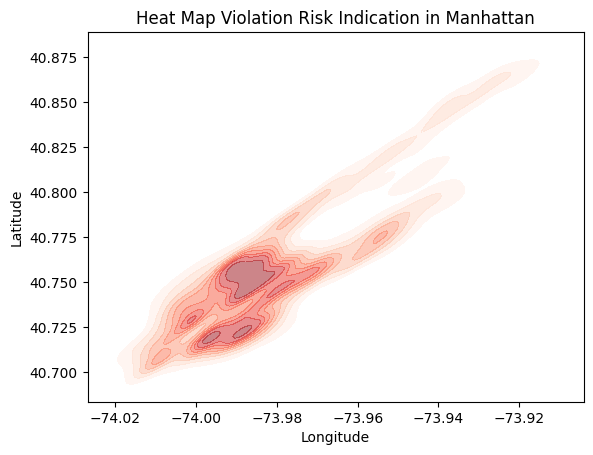

In [143]:
# Heat Map (KDE plot) visualizing the areas of high risk with the darker colors indicating higher risks
## the darker red represents the higher probability of encountering a violation.
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    x=data['Longitude'],
    y=data['Latitude'],
    fill=True,
    cmap="Reds",
    alpha=0.5
)

plt.title("Heat Map Violation Risk Indication in Manhattan")
plt.show()

This heat map represents the hotspots that indicate a higher probability of encountering an inspection violation. The darker colored areas indicate a higer concentration of violations.

The lighter shades of red fading display how the risk spreads out across the borough. This map is useful in identifying broad risk zones.

In [144]:
print(data.columns)

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location'],
      dtype='object')


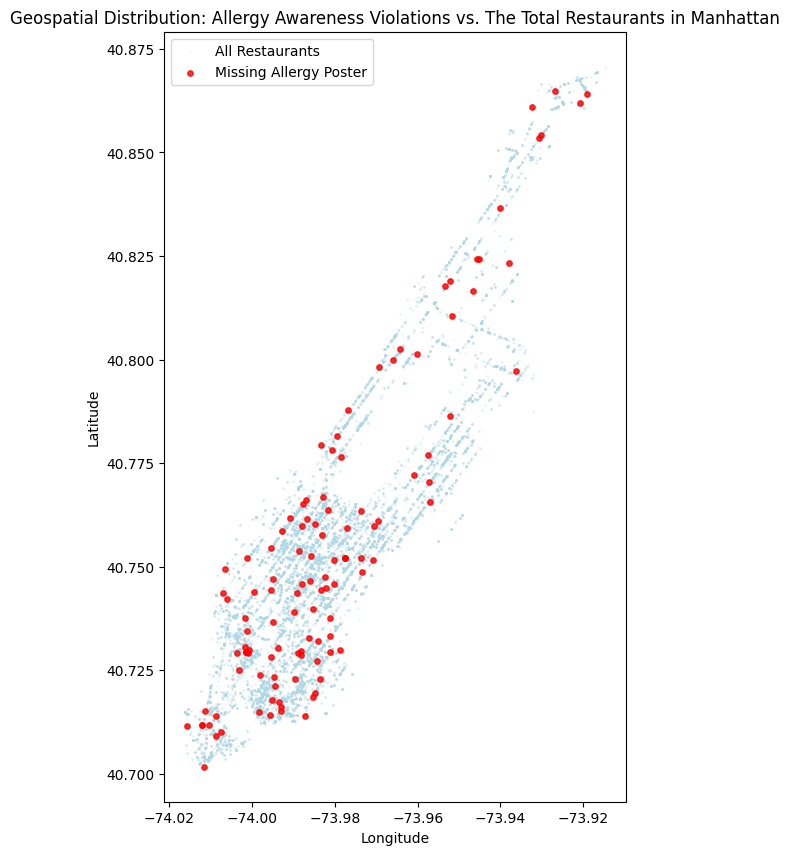

In [145]:
# The poster violations
allergy_poster_map = data[data['VIOLATION CODE'] == '20-01']

plt.figure(figsize=(8, 10))

# plotting all Manhattan restaurants in the background
plt.scatter(
    data['Longitude'],
    data['Latitude'],
    color='lightblue',
    alpha=0.1,
    s=1, #all the restaurants in Manhattan are plotted in light blue as a base
    label='All Restaurants'
)

# plotting the 117 Allergy poster violations on top of the the base of ALL restaurants (light blue dots)
plt.scatter(
    allergy_poster_map['Longitude'],
    allergy_poster_map['Latitude'],
    color='red',
    alpha=0.8,
    s=15, #larger points for easy differentiation
    label='Missing Allergy Poster'
)

plt.title("Geospatial Distribution: Allergy Awareness Violations vs. The Total Restaurants in Manhattan")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

# Fix the aspect ratio so Manhattan isn't 'stretched'
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

This visualization displays two perspectives on food allergy compliance. The smaller light blue dots represent the total inspected restaurants, essentially mapping the dining scene of Manhattan, acting as a control group. The bigger red dots represent specific instances that were noted by the NYCDOHMH inspection team where the required Food Allergy Information Poster (Violation 20-01) was missing.

By the layering of both the total population of inspected restaurants and the allergy poster violations we can note that the poster violations are not soley the byproduct of high restaurant density. The red points represent an opportunity to remedy the gap by an allergy educational outreach that can improve the safety of the allergy population.

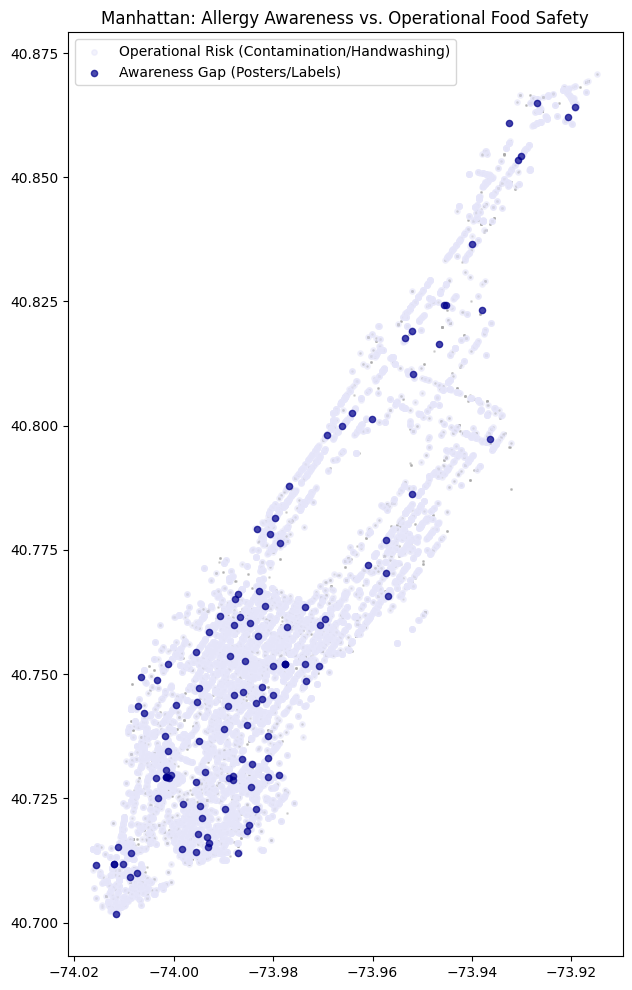

In [146]:
plt.figure(figsize=(10, 12))

#The basline: all Manhattan restaurants (small red dots)
## the small dark gray dots act as a baseline and are the most bottom layer (background) representing all restaurants in Manhattan (the whole population)
plt.scatter(data['Longitude'], data['Latitude'], color='darkgray', alpha=0.4, s=1)

#1st Layer: Physical Risk
plt.scatter(
    risk_df['Longitude'],
    risk_df['Latitude'],
    color='lavender',
    alpha=0.5,
    s=15,
    label='Operational Risk (Contamination/Handwashing)'
)

#2nd Layer: Awareness
plt.scatter(
    allergy_df['Longitude'],
    allergy_df['Latitude'],
    color='darkblue',
    alpha=0.7,
    s=20,
    label='Awareness Gap (Posters/Labels)'
)


plt.title("Manhattan: Allergy Awareness vs. Operational Food Safety")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

This visualization compares the allergy awareness gaps (the posters and safety labels) against operational failures (cross-contamination, poor handwashing, and unsanitary surfaces).

The small dark grey dots in the background act as a baseline, representing the total population of inspected restaurants across Manhattan to control for the overall restaurant density.

This chart dives deeper into investigating the geographic or spatial correlations to answer the question:
>*Are establishments with allergy awareness gaps fundamentally more careless across all safety realms or are they two different independent issues requiring different interventions and public health strategies?*

If they are, the dark blue dots will cluster directly on top of heavy concentrations of lavender operational risk dots. If they do not overlap, it suggests these are two independent operational challenges, indicating a neighborhood may need targeted educational outreach rather than increased standard health code enforcement.


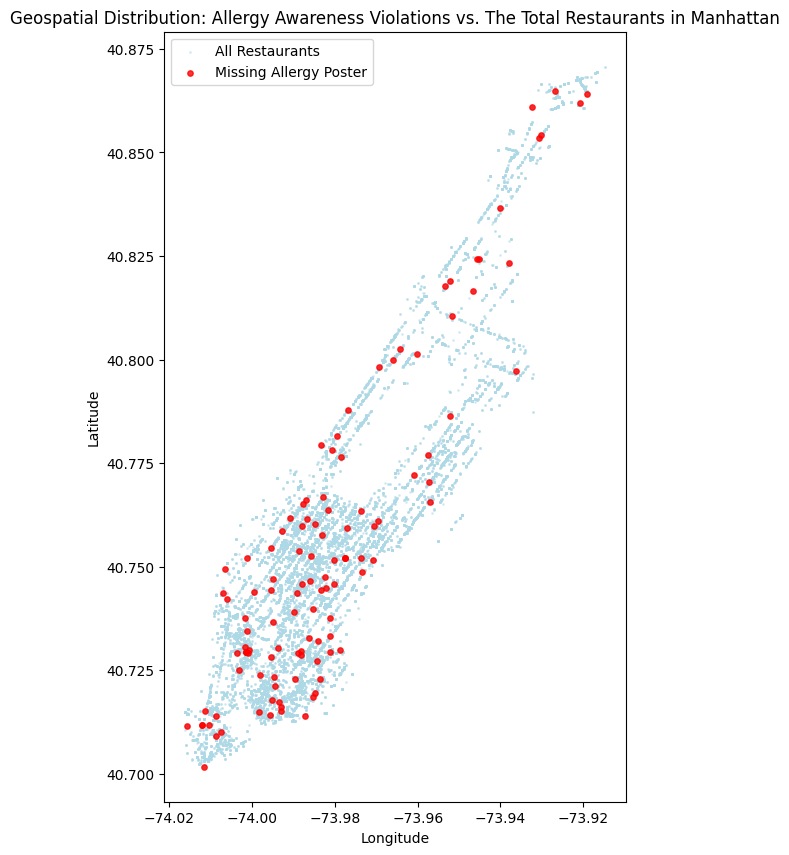

In [147]:
# The poster violations
allergy_poster_map = data[data['VIOLATION CODE'] == '20-01']

plt.figure(figsize=(8, 10))

# plotting all Manhattan restaurants in the background
plt.scatter(
    data['Longitude'],
    data['Latitude'],
    color='lightblue',
    alpha=0.4,
    s=1, #all the restaurants in Manhattan are plotted in light blue as a base
    label='All Restaurants'
)

# plotting the 117 Allergy poster violations on top of the the base of ALL restaurants (light blue dots)
plt.scatter(
    allergy_poster_map['Longitude'],
    allergy_poster_map['Latitude'],
    color='red',
    alpha=0.8,
    s=15, #larger points for easy differentiation
    label='Missing Allergy Poster'
)

plt.title("Geospatial Distribution: Allergy Awareness Violations vs. The Total Restaurants in Manhattan")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

# Fix the aspect ratio so Manhattan isn't 'stretched'
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

This visualization isolates NYC DOHMH Violation Code 20-01: *Food allergy information poster not conspicuously posted where food is being prepared or processed.*

By mapping the 117 instances of this particular violation against a baseline (the control) of all active Manhattan restaurant inspections (in light blue), we can evaluate the geospatial distribution of compliance of displayed allergy posters.

If poster violations were strictly a byproduct of a high restaurant volume, the red markers would parallel the density patterns of the background control map (for instance, heavily clustering of red dots in popular areas of Manhattan).

The areas of higher density of red dots, can represent an opportunity for public health outreach by providing multi-lingual (according to the languages most spoken in the certain areas) poster drop-offs and education in these specific areas which can instantly protect vulnerable food-allergic consumers as the efforts may address a Social determinants of health (SDOH).

# **Statisical Visualizations**

In [148]:
allergy_compliance_df


,ZIPCODE,RESTAURANTS,ALLERGY AWARENESS,ALLERGY & FOOD SAFETY,CRITICAL,ALLERGY_AWARENESS_RATE,ALLERGY_RISK_RATE,CRITICAL_RATE
0,10001.0,442,4.0,5.0,974.0,0.009050,0.011312,2.203620
1,10002.0,356,9.0,9.0,1017.0,0.025281,0.025281,2.856742
2,10003.0,443,7.0,7.0,1039.0,0.015801,0.015801,2.345372
3,10004.0,93,1.0,1.0,193.0,0.010753,0.010753,2.075269
4,10005.0,34,0.0,0.0,70.0,0.000000,0.000000,2.058824
...,...,...,...,...,...,...,...,...
72,10179.0,1,0.0,0.0,5.0,0.000000,0.000000,5.000000
73,10271.0,2,0.0,0.0,2.0,0.000000,0.000000,1.000000
74,10280.0,18,1.0,1.0,50.0,0.055556,0.055556,2.777778
75,10281.0,14,0.0,0.0,18.0,0.000000,0.000000,1.285714


In [149]:
allergy_risk_foodsafety

,0
ZIPCODE,
10001.0,5
10002.0,9
10003.0,7
10004.0,1
10007.0,5
10009.0,5
10010.0,3
10011.0,6
10012.0,10


In [150]:
allergy_awareness

,0
ZIPCODE,
10001.0,4
10002.0,9
10003.0,7
10004.0,1
10007.0,5
10009.0,5
10010.0,3
10011.0,6
10012.0,10


/tmp/ipykernel_14518/2405064646.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


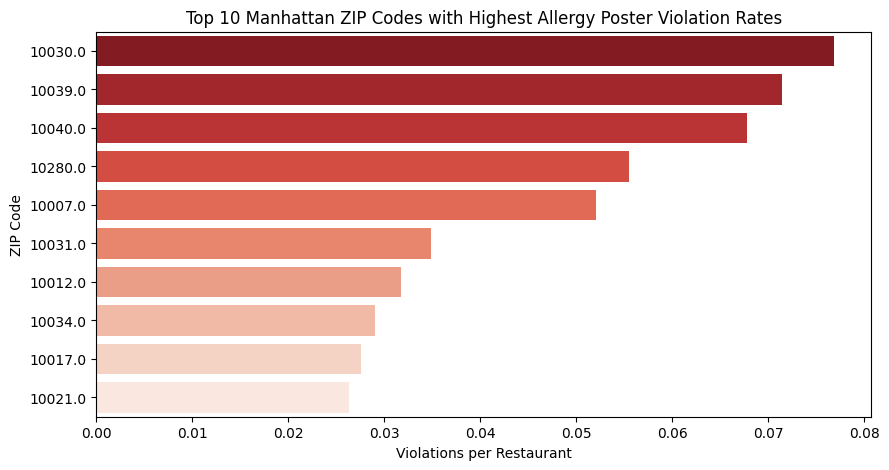

In [151]:
# Bar chart
## for the Top 10 zip codes with the highest allergy awareness poster violation rates
top_10_poster_violations = top_risk_neighborhoods.sort_values(by='ALLERGY_AWARENESS_RATE', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x='ALLERGY_AWARENESS_RATE',
    y=top_10_poster_violations['ZIPCODE'].astype(str),
    data=top_10_poster_violations,
    palette='Reds_r'
)
plt.title('Top 10 Manhattan ZIP Codes with Highest Allergy Poster Violation Rates')
plt.xlabel('Violations per Restaurant')
plt.ylabel('ZIP Code')
plt.show()

**The Zip Codes with the highest allergy poster violations:**
1) 10030 - Central Harlem
2) 10039 - Harlem
3) 10040 - Washington Heights & Inwood
4) 10280 - Battery Park City
5) 10007 - Tribeca & Civic Center
6) 10031 - Hamilton Heights
7) 10012 - SoHo & Greenwich Village
8) 10034 - Inwood
9) 10017 - Midtown East & Turtle Bay
10) 10021 - Upper East Side


In [152]:
# comprehensive results of the top 10 highest risk neighborhoods in Manhattan based on the critical health violations per restaurant all the results, to understand the visualizations better
allergy_compliance_df.sort_values(by='CRITICAL_RATE', ascending=False).head(10)

,ZIPCODE,RESTAURANTS,ALLERGY AWARENESS,ALLERGY & FOOD SAFETY,CRITICAL,ALLERGY_AWARENESS_RATE,ALLERGY_RISK_RATE,CRITICAL_RATE
72,10179.0,1,0.0,0.0,5.0,0.000000,0.000000,5.000000
27,10030.0,13,1.0,1.0,62.0,0.076923,0.076923,4.769231
37,10040.0,59,4.0,4.0,202.0,0.067797,0.067797,3.423729
13,10016.0,284,5.0,5.0,844.0,0.017606,0.017606,2.971831
30,10033.0,85,0.0,0.0,252.0,0.000000,0.000000,2.964706
23,10026.0,40,0.0,0.0,118.0,0.000000,0.000000,2.950000
31,10034.0,69,2.0,2.0,200.0,0.028986,0.028986,2.898551
76,10282.0,9,0.0,0.0,26.0,0.000000,0.000000,2.888889
1,10002.0,356,9.0,9.0,1017.0,0.025281,0.025281,2.856742
56,10128.0,110,1.0,1.0,313.0,0.009091,0.009091,2.845455


# **Conclusion & Public Health Strategies**

## Project Summary
This analysis moved past high-level restaurant inspection scores to isolate the specific public health threats facing the food allergy population in Manhattan. This project evaluated the geospatial distribution of both regulatory awareness gaps (Violation Code 20-01: Missing Food Allergy Posters) as well as operational health inspection failures (cross-contamination, poor handwashing, etc.).

Instead of relying on the raw data, which would naturally skew a little biased towards high-density areas, this study utilized normalized statistics to objectively identify neighborhood-level compliance deviations.

## Insights From the Analysis

- **Restaurant Volume Density vs. Risk Rates (Decentering Volume from Risks):**
   The geospatial layering as shown in the visualizations show, how public health risks are independently explored compared to strictly aligning it to  restaurant density. High-density areas such as zipcodes in the Lower East Side (10002), hold higher numbers of violations due to the larger number of establishments in the specific zip code compared to other zipcodes, but have a lower number risk rates. The opposite can be seen with zipcodes with fewer restaurants but higher number of violations and risks. This can indicate that higher volumes of restaurants do not directly indicate non-compliance, and other factors such as Social determinants of health (SDOH) should be evaluated when looking at the data.

- **Compliance Intersections (Safety & Awareness Overlaps):**
   Through the layering geospatial analysis and compliance analysis metrics, zipcodes 10030 (Harlem) and 10040 (Washington Heights) emerged as the front-runners for high-priority focus areas as these neighborhoods not only suffer from a higher frequency of critical sanitary failures (`CRITICAL_RATE` > 3.4); they also simultaneously have higher informational shortcomings, with up to 7.6% of establishments lacking mandatory allergy safety and information posters. This intersection indicates that general operational health violations during inspections likely also directly correlate with gaps in fundamental allergy-awareness protocols which protect the food-allergic community and population. This further opens the opportunity for more educational resources to be allocated to such zipcodes to decrease adverse health outcomes due to the lack of widespread awareness, especially towards food allergies.

## Bias Mitigation & Data Ethics
In alignment with the data ethics framework, these **localized specific hot spots must NOT be used to stigmatize specific neighborhoods, cuisines and food cultures. Higher violation rates in these neighborhoods DO NOT reflect the neighborhood's character, and instead, they serve as indicators of Social Determinants of Health (SDoH)**. Rooted in the guidelines set by the CDC and Healthy People 2030, These spots represent disparities which can lead to adverse health outcomes due to a wide variety of factors such as lack of access to regulatory and educational resources, socioeconomic, and or language barriers.

## Data-Driven Public Health Recommendations & Strategies
To close the gap between patient safety and compliance, the NYCDOHMH can look into pivot to **precision resource allocations  by:**

- **Targeting Multi-Lingual Posters & Informationals:** A prioritization of physical drop-offs for Food Allergy Posters (Violation Code: 20-01) can focus on the dominant languages spoken in those specific neighborhoods, along with the standard English poster. This would not only increase compliance with DOH's inspection regulations but increase allergy and health outcomes awareness in the general population.

- **SDOH-Informed Educational Interventions:** Instead of relying solely on health fines, which can increase operational and economic strains in under-resourced neighborhoods, the city can deploy free, localized food allergy safety and cross-contamination prevention workshops directly to business owners in higher rate zip codes to structurally lower operational and health risks.



### References & Literature
- **Social Determinants of Health Framework:** U.S. Department of Health and Human Services, Office of Disease Prevention and Health Promotion. *Healthy People 2030*. [health.gov/healthypeople](https://health.gov/healthypeople/priority-areas/social-determinants-health).

- **Public Health Impact:** Centers for Disease Control and Prevention (CDC). *Why Addressing Social Determinants of Health is Important for Public Health*. [cdc.gov/about/priorities](https://www.cdc.gov/about/priorities/why-is-addressing-sdoh-important.html).
